In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

TICKERS = ["ZAMAUSDT", "WIFUSDT"]
DATES   = ["2026-04-12", "2026-04-13", "2026-04-14"]
ALGOS   = ["Quote Rule", "Tick Rule", "Lee-Ready"]
BASE    = Path("../task_data")

## 1. Data Loading & Classification — All Tickers × All Dates

In [2]:
all_results = {}  # (ticker, date, algo) -> (y_true, y_pred)

for ticker in TICKERS:
    for date in DATES:
        ob = pd.read_parquet(BASE / ticker / f"{ticker}_orderbook_{date}.parquet")
        tr = pd.read_parquet(BASE / ticker / f"{ticker}_trades_{date}.parquet")

        mid = ((ob['ask0'] + ob['bid0']) / 2).rename('spread mid point')
        pm = pd.merge_asof(tr, mid.to_frame(), left_index=True, right_index=True, direction='backward')
        pm = pm[['price', 'spread mid point', 'side']]
        tick_filled = np.sign(tr['price'].diff()).replace(0, np.nan).ffill()

        # Quote Rule
        qr = pd.Series(
            np.select([pm['price'] < pm['spread mid point'], pm['price'] > pm['spread mid point']],
                      [True, False], default=None),
            index=pm.index
        )
        f = pd.concat([pm[['side']], qr.rename('pred')], axis=1).dropna()
        all_results[(ticker, date, 'Quote Rule')] = (f['side'].astype(bool), f['pred'].astype(bool))

        # Tick Rule
        tr_s = pd.Series(
            np.select([tick_filled > 0, tick_filled < 0], [False, True], default=None),
            index=tr.index
        )
        f = pd.concat([tr[['side']], tr_s.rename('pred')], axis=1).dropna()
        all_results[(ticker, date, 'Tick Rule')] = (f['side'].astype(bool), f['pred'].astype(bool))

        # Lee-Ready
        at_mid = pm['price'] == pm['spread mid point']
        lr = pd.Series(
            np.select([pm['price'] < pm['spread mid point'], pm['price'] > pm['spread mid point'],
                       at_mid & (tick_filled < 0), at_mid & (tick_filled > 0)],
                      [True, False, True, False], default=None),
            index=pm.index
        )
        f = pd.concat([pm[['side']], lr.rename('pred')], axis=1).dropna()
        all_results[(ticker, date, 'Lee-Ready')] = (f['side'].astype(bool), f['pred'].astype(bool))

print(f"Loaded {len(all_results)} combinations ({len(TICKERS)} tickers × {len(DATES)} dates × {len(ALGOS)} algos)")

Loaded 18 combinations (2 tickers × 3 dates × 3 algos)


## 2. Summary Table

In [3]:
records = []
for (ticker, date, algo), (y_true, y_pred) in all_results.items():
    r = classification_report(y_true, y_pred, target_names=['Buy', 'Sell'], output_dict=True)
    records.append({
        'Ticker': ticker, 'Date': date, 'Algorithm': algo,
        'Samples': len(y_true),
        'Accuracy': r['accuracy'],
        'Buy F1': r['Buy']['f1-score'],
        'Sell F1': r['Sell']['f1-score'],
        'Macro F1': r['macro avg']['f1-score'],
    })

summary = pd.DataFrame(records).set_index(['Ticker', 'Date', 'Algorithm'])
summary.style \
    .format({'Accuracy': '{:.4f}', 'Buy F1': '{:.4f}', 'Sell F1': '{:.4f}', 'Macro F1': '{:.4f}'}) \
    .highlight_max(subset=['Accuracy', 'Buy F1', 'Sell F1', 'Macro F1'], color='lightgreen')

## 3. Visual Comparison

### 3a. Confusion Matrices — ZAMAUSDT (all dates × all algorithms)

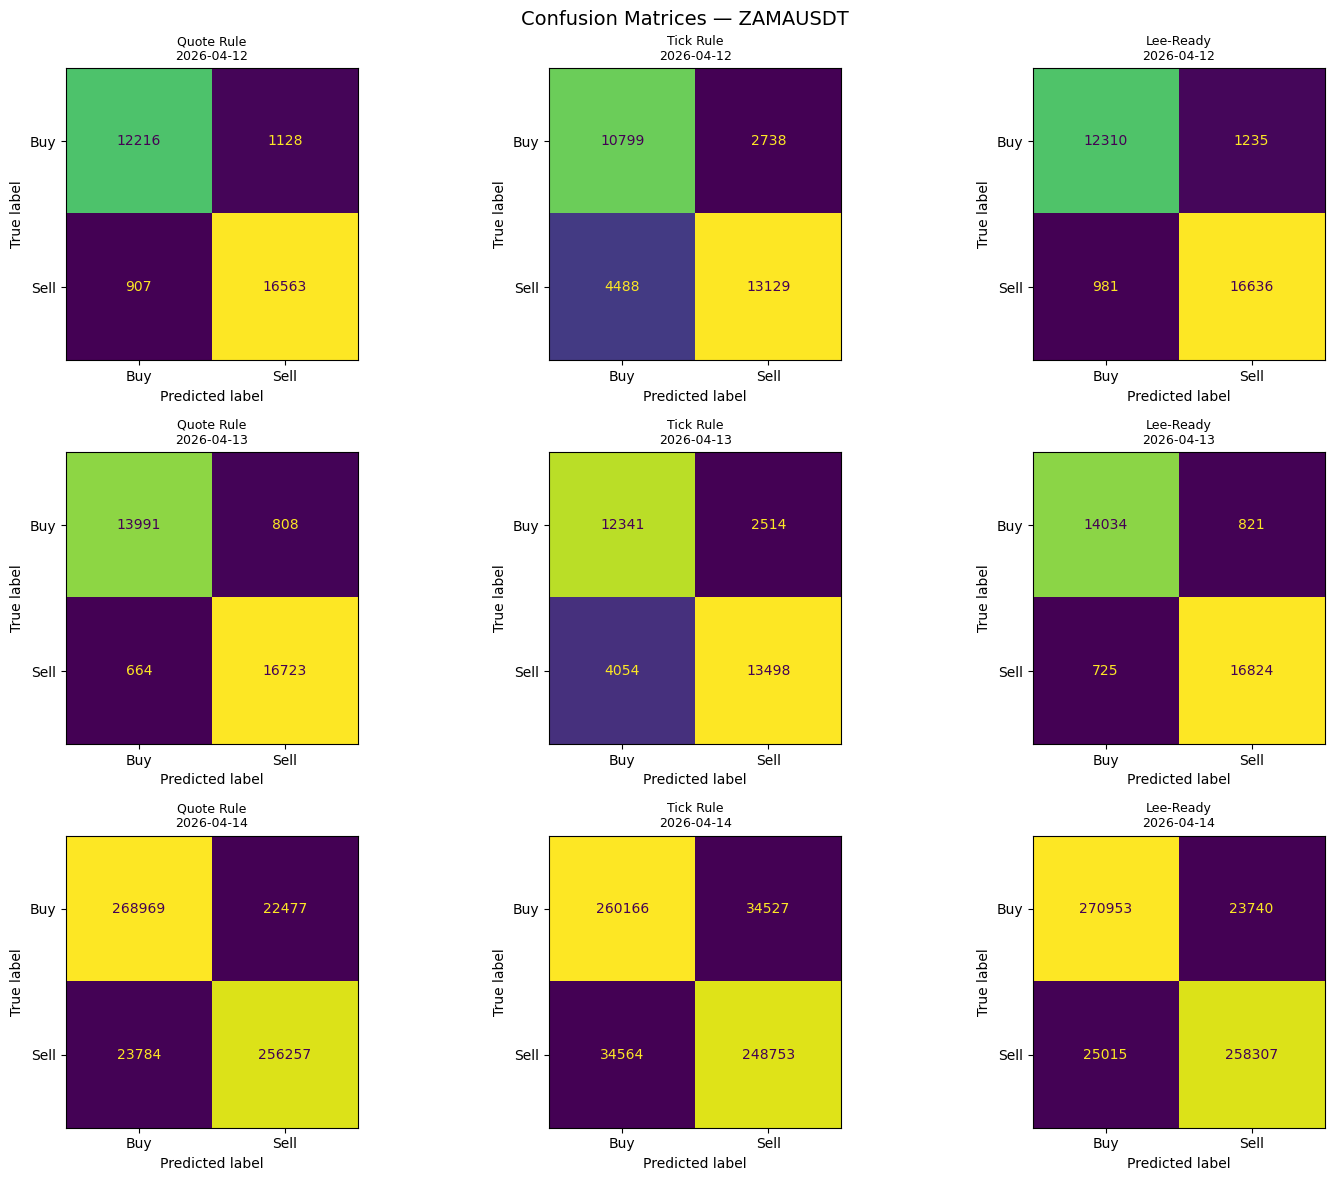

In [4]:
ticker = "ZAMAUSDT"
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for row_idx, date in enumerate(DATES):
    for col_idx, algo in enumerate(ALGOS):
        y_true, y_pred = all_results[(ticker, date, algo)]
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, display_labels=['Buy', 'Sell'], colorbar=False,
            ax=axes[row_idx][col_idx]
        )
        axes[row_idx][col_idx].set_title(f"{algo}\n{date}", fontsize=9)

fig.suptitle(f'Confusion Matrices — {ticker}', fontsize=14)
plt.tight_layout()
plt.show()

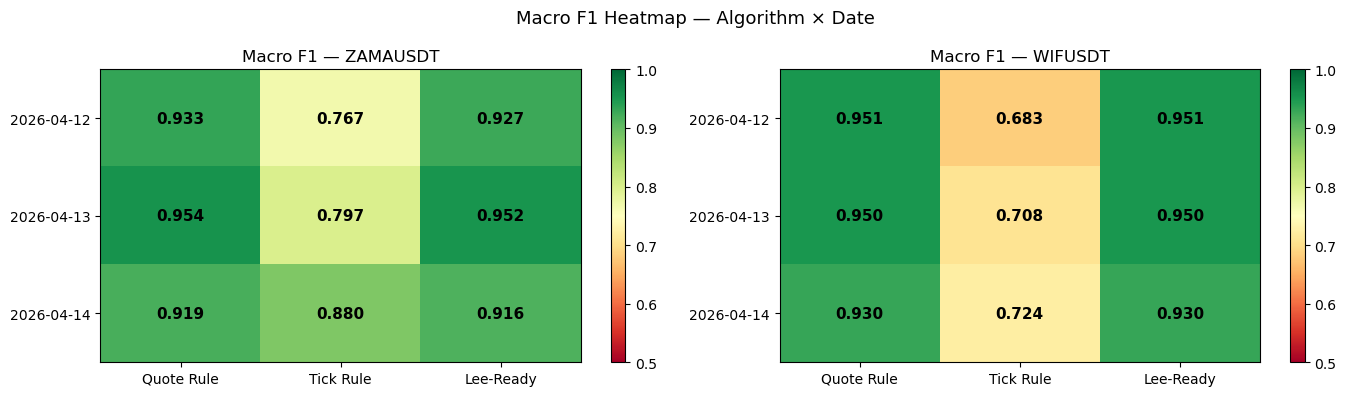

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, ticker in zip(axes, TICKERS):
    matrix = [
        [classification_report(*all_results[(ticker, date, algo)], output_dict=True)['macro avg']['f1-score']
         for algo in ALGOS]
        for date in DATES
    ]
    df_heat = pd.DataFrame(matrix, index=DATES, columns=ALGOS)
    im = ax.imshow(df_heat.values, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(len(ALGOS))); ax.set_xticklabels(ALGOS)
    ax.set_yticks(range(len(DATES))); ax.set_yticklabels(DATES)
    ax.set_title(f'Macro F1 — {ticker}')
    for i in range(len(DATES)):
        for j in range(len(ALGOS)):
            ax.text(j, i, f'{df_heat.iloc[i, j]:.3f}', ha='center', va='center',
                    fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax)

fig.suptitle('Macro F1 Heatmap — Algorithm × Date', fontsize=13)
plt.tight_layout()
plt.show()